# Exercises
_Rijcklof Hofman s4792432_

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import numpy as np
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data
import lfp_functions as lf
import scipy

# sns.set_theme(context='notebook',style='white',font_scale=1.5,
#               rc = {'axes.spines.top':False,'axes.spines.right':False,
#                      'image.cmap':plt.cm.jet})

sns.set_theme(context='notebook',style='white',font_scale=1.5,
               rc = {'axes.spines.top':False,'axes.spines.right':False})

download_data('https://surfdrive.surf.nl/files/index.php/s/9nY01qMimFLez40')



## Exercise 1: explore filter parameters
---
In this exercises you will explore how different parameters affect the filtering process.
- Import the data form `data/moving_lfp.pickle` (the file is already on your machine if you run the `download_data()` cell in the main lesson)
- Take a few seconds of the data, and filter them in different frequency bands. Plot the resulting singal.
  Fix the central frequency and play with the width of the band, then try to change the central frequency of the band.
- Change the order of the filter, keeping the frequency band fixed. How does the filtered signal change? How does the computing time change? (You can try to quantify the computing time with the jupyter magic command [`%timeit`](https://docs.python.org/3/library/timeit.html) )
- Comment on what you see

In [6]:
from scipy.fft import fft, fftfreq
from scipy.signal import butter
from scipy.signal import sosfilt

In [2]:
with open('data/moving_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)

lfp = lfp_data['lfp']
sampling_rate = lfp_data['sampling_rate']
print(f'Loaded {len(lfp)/sampling_rate} seconds of LFP, sampled at {sampling_rate} Hz')

Loaded 600.133 seconds of LFP, sampled at 1000.0 Hz


In [9]:
t_start = 3. #The starting point of the analyzed data
t_end = 6. #The ending point of the analysed data
data_1 = lfp[int(t_start*sampling_rate):int(t_end*sampling_rate)] #The analysed data for excercise 1
centered_data_1 = data_1 - np.mean(data_1)

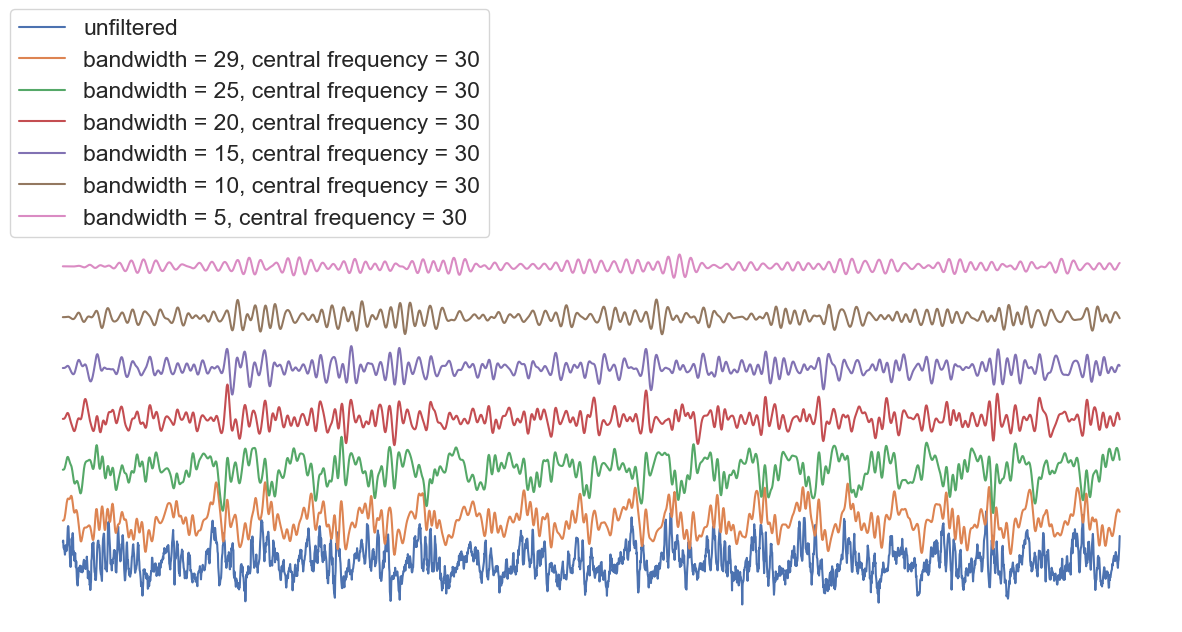

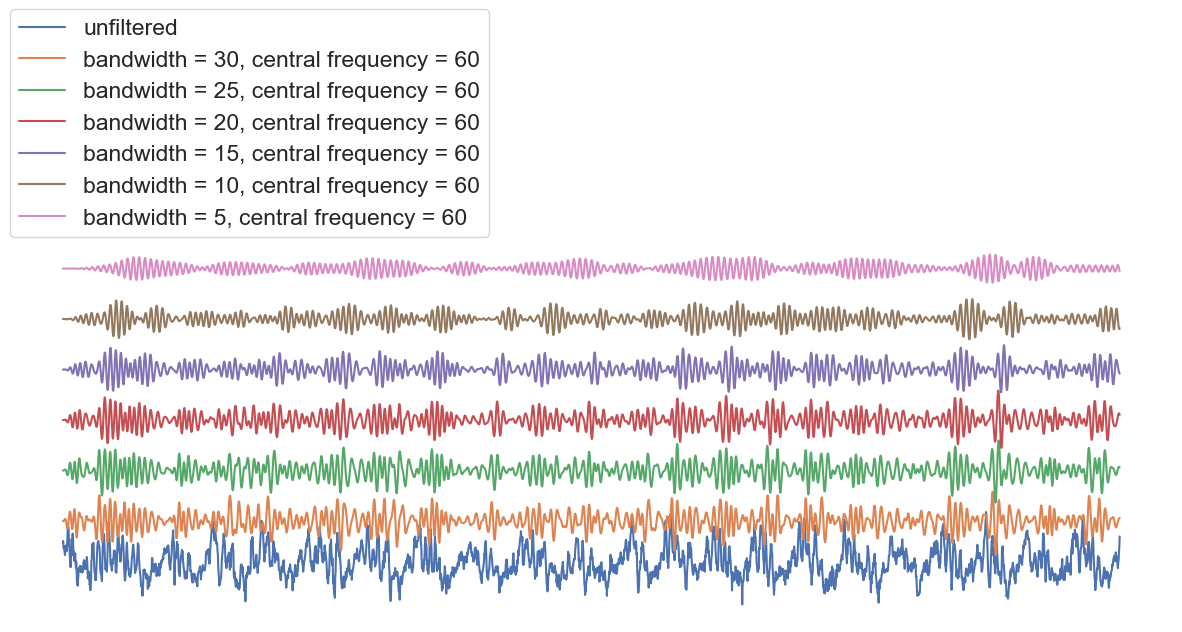

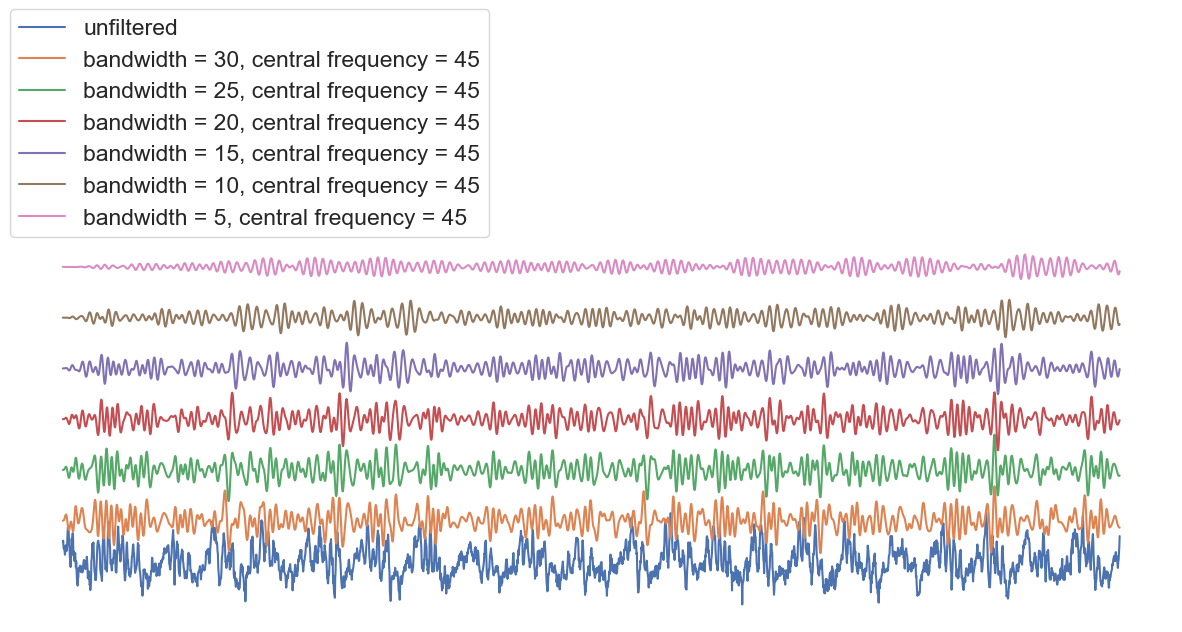

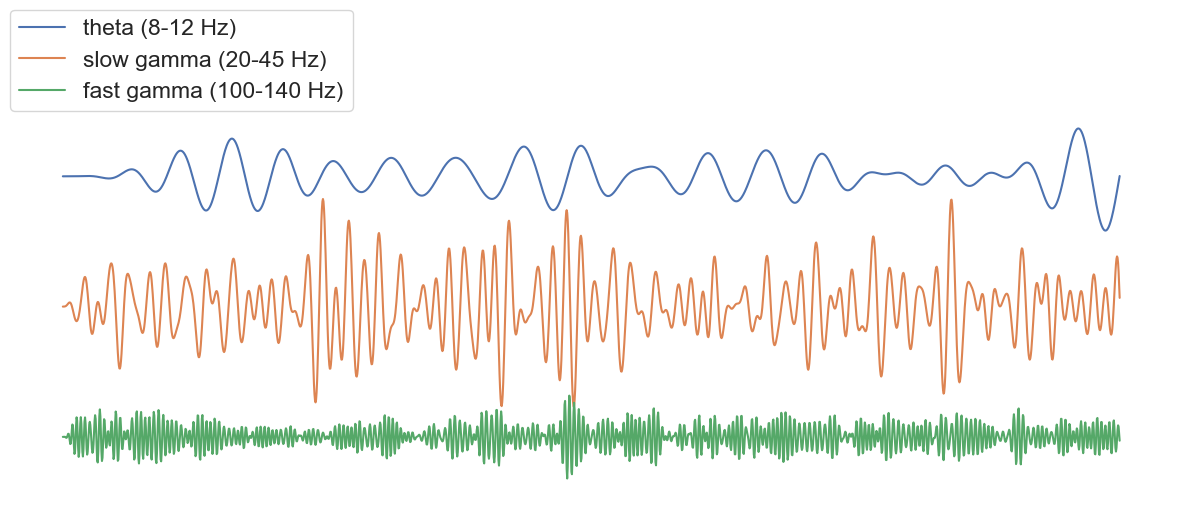

In [36]:
central_f = 30

bandwidths = np.array([29,25,20,15,10,5])
plot_offset = 400 #to plot the signal on different lines

plt.figure(figsize=(15,5))
plt.plot(data_1,label=f'unfiltered')
#plt.plot(data_1+len(bandwidths)*plot_offset,label=f'unfiltered')

for i in range(len(bandwidths)):
    filtered_data = lf.bandpass_filter(data_1,low_f=central_f-bandwidths[i],high_f=central_f+bandwidths[i], sampling_rate=sampling_rate)
    plt.plot(filtered_data+(i+1)*plot_offset,label=f'bandwidth = {bandwidths[i]}, central frequency = {central_f}')

plt.axis('off')
plt.legend(loc=(0,1))
plt.show()
plt.close()

central_f = 60

bandwidths = np.array([30,25,20,15,10,5])
plot_offset = 400 #to plot the signal on different lines

plt.figure(figsize=(15,5))
plt.plot(data_1,label=f'unfiltered')
#plt.plot(data_1+len(bandwidths)*plot_offset,label=f'unfiltered')

for i in range(len(bandwidths)):
    filtered_data = lf.bandpass_filter(data_1,low_f=central_f-bandwidths[i],high_f=central_f+bandwidths[i], sampling_rate=sampling_rate)
    plt.plot(filtered_data+(i+1)*plot_offset,label=f'bandwidth = {bandwidths[i]}, central frequency = {central_f}')

plt.axis('off')
plt.legend(loc=(0,1))
plt.show()
plt.close()

central_f = 45

bandwidths = np.array([30,25,20,15,10,5])
plot_offset = 400 #to plot the signal on different lines

plt.figure(figsize=(15,5))
plt.plot(data_1,label=f'unfiltered')
#plt.plot(data_1+len(bandwidths)*plot_offset,label=f'unfiltered')

for i in range(len(bandwidths)):
    filtered_data = lf.bandpass_filter(data_1,low_f=central_f-bandwidths[i],high_f=central_f+bandwidths[i], sampling_rate=sampling_rate)
    plt.plot(filtered_data+(i+1)*plot_offset,label=f'bandwidth = {bandwidths[i]}, central frequency = {central_f}')

plt.axis('off')
plt.legend(loc=(0,1))
plt.show()
plt.close()

theta_lfp = lf.bandpass_filter(data_1,low_f=8,high_f=12, sampling_rate=sampling_rate)
slow_gamma_lfp = lf.bandpass_filter(data_1,low_f=20,high_f=45, sampling_rate=sampling_rate)
fast_gamma_lfp = lf.bandpass_filter(data_1,low_f=100,high_f=140, sampling_rate=sampling_rate)

plot_offset = 200 #to plot the signal on different lines
plt.figure(figsize=(15,5))
plt.plot(theta_lfp[:2000]+2*plot_offset,label='theta (8-12 Hz)')
plt.plot(slow_gamma_lfp[:2000]+plot_offset,label = 'slow gamma (20-45 Hz)')
plt.plot(fast_gamma_lfp[:2000],label = 'fast gamma (100-140 Hz)')

plt.axis('off')
plt.legend(loc=(0,1))

417 μs ± 8.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
418 μs ± 14 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
461 μs ± 14.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
460 μs ± 11.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
460 μs ± 17.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
456 μs ± 11.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.16 ms ± 73.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.13 ms ± 19.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.11 ms ± 20.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.1 ms ± 13.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.11 ms ± 45.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.12 ms ± 21.8 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.94 ms ± 54.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.02 ms ± 168 μs per loop (mean ± std. dev. of 7 r

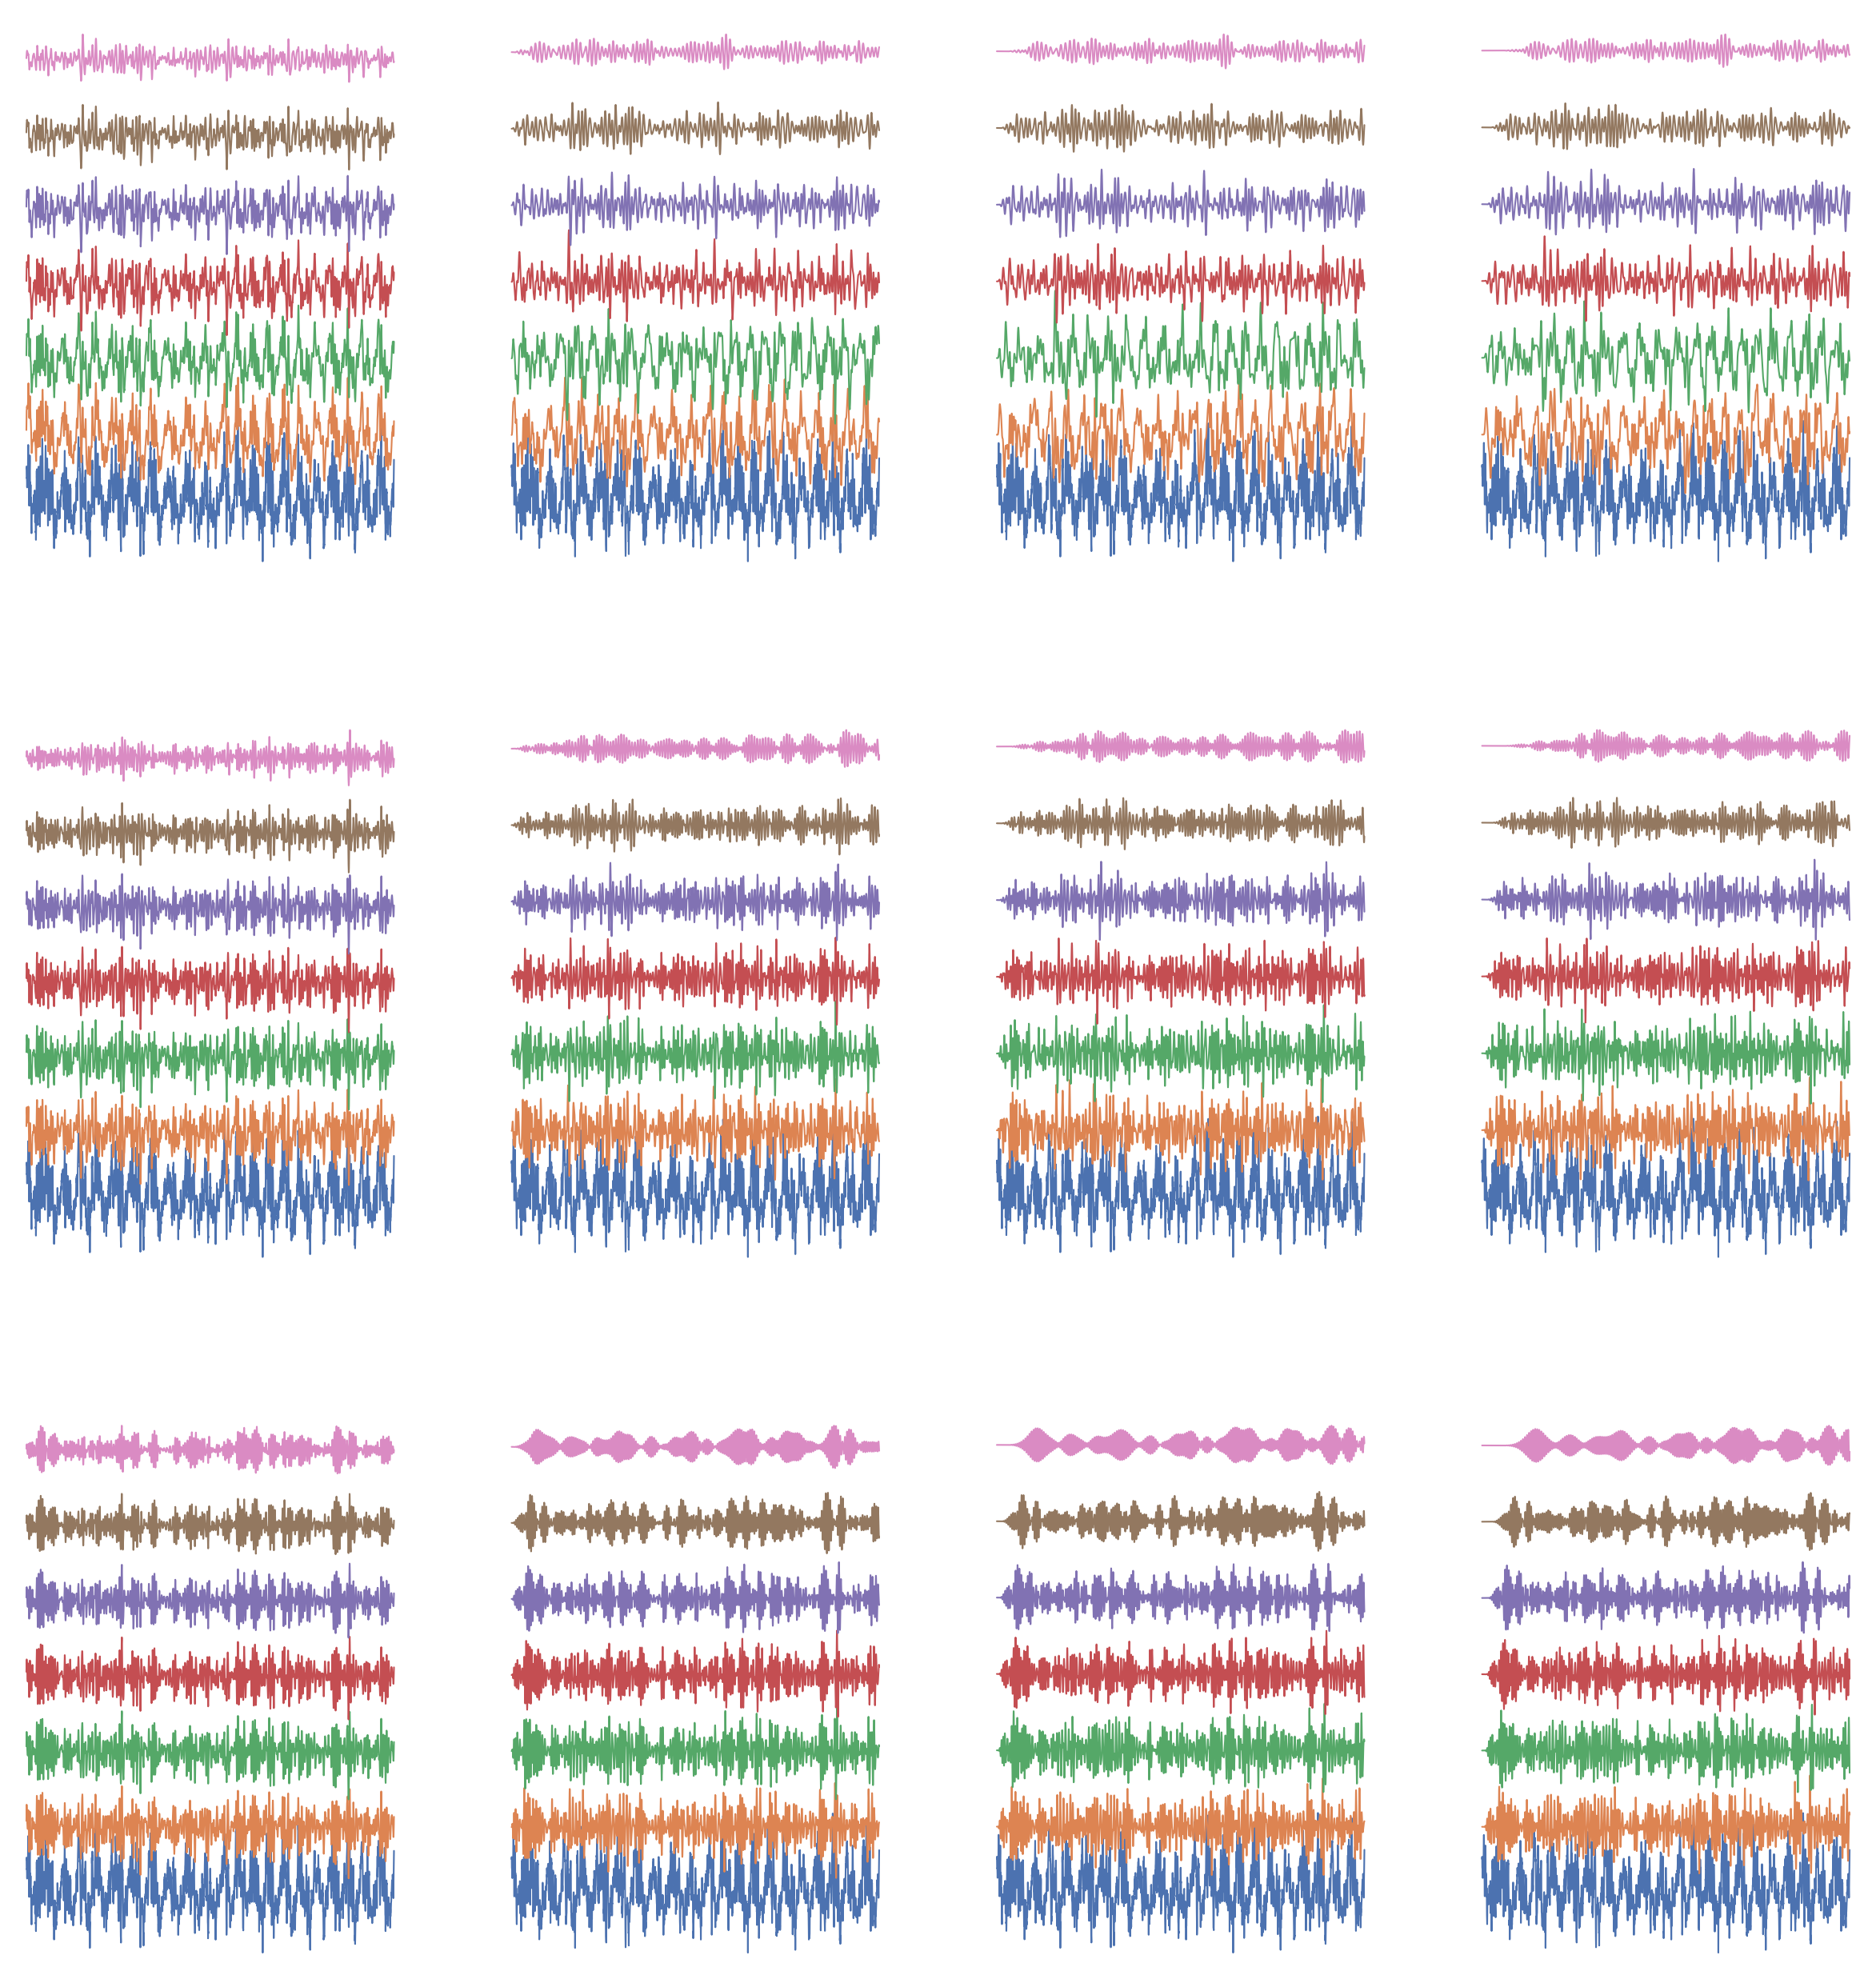

In [37]:
orders = np.array([1,5,10,15])
central_fs = np.array([30,45,60])

fig,axs = plt.subplots(len(central_fs),len(orders),figsize=(30,32))
for k in range(len(central_fs)):
    central_f = central_fs[k]
    for j in range(len(orders)):
        bandwidths = np.array([30,25,20,15,10,5])
        plot_offset = 400 #to plot the signal on different lines
        
        axs[k,j].plot(data_1,label=f'unfiltered')
        #plt.plot(data_1+len(bandwidths)*plot_offset,label=f'unfiltered')
        
        for i in range(len(bandwidths)):
            if bandwidths[i] == central_f: 
                %timeit lf.bandpass_filter(data_1,low_f=central_f-bandwidths[i]+1,high_f=central_f+bandwidths[i]-1, sampling_rate=sampling_rate,filter_order=orders[j])
                filtered_data = lf.bandpass_filter(data_1,low_f=central_f-bandwidths[i]+1,high_f=central_f+bandwidths[i]-1, sampling_rate=sampling_rate,filter_order=orders[j])
            else:
                %timeit lf.bandpass_filter(data_1,low_f=central_f-bandwidths[i],high_f=central_f+bandwidths[i], sampling_rate=sampling_rate,filter_order=orders[j])
                filtered_data = lf.bandpass_filter(data_1,low_f=central_f-bandwidths[i],high_f=central_f+bandwidths[i], sampling_rate=sampling_rate,filter_order=orders[j])
            axs[k,j].plot(filtered_data+(i+1)*plot_offset,label=f'bandwidth = {bandwidths[i]}, central frequency = {central_f}')
        
        axs[k,j].axis('off')
        #if j == 0: axs[k,j].legend(loc=(0,1),title=f'Order = {orders[j]}')
plt.show()
plt.close()

__Some Comments:__
- The tighter the band becomes (so smaller bandwidth) the more "smooth" the signal becomes. This makes sensce, because the smaller the bandwidth the more the passed frequencies are similar, resulting less oscilations of a very different frequency, which make the signal look "jagged" instead of "smooth."
- By changing the central frequency of the band, the resulting signals keep differing amounts of their amplitude, showing that some frequencys are more or less present in the original signal.
- Increasing the order of the filter makes the resulting signal more smooth, showing that it has a better filtering property. But this effect appears to be suffering of the "diminishing returns" problem, where the difference between order 1 and 5 is the biggest (at least to the naked eye), and there are barely any big inprovements from 5 to 10 or from 10 to 15.
- The comuting time seems to increase linearly with the order of the filter. Which I thought to be "not so bad", as I feared it might well turn out to be in a more extreme order. But given the diminishing returns, one should still opt for an order that is good enough, but doesn't take to much time to compute.

## Exercise 2: wavelet transform with real wavelets
---
In this exercises you will explore the difference between real and complex wavelets in the continous wavelet transform.
- Import the data form `data/moving_lfp.pickle`
- Select a period of a few seconds of the signal and compute the spectrogram. 
  Try the wavelet transform with wavelet `mexh` (mexican hat),`gaus` (gaussian) and `morl` (morlet). These are all real wavelets.
- What differences do you see with respect to the spectrum computed with the complex Morlet tranform ? Comment on why do you think this might be the case.

In [39]:
from ipywidgets import interact
import ipywidgets as widgets
import pywt
from pywt import wavelist
from pywt import scale2frequency
from pywt import cwt


In [40]:
with open('data/moving_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)

lfp = lfp_data['lfp']
sampling_rate = lfp_data['sampling_rate']
print(f'Loaded {len(lfp)/sampling_rate} seconds of LFP, sampled at {sampling_rate} Hz')

Loaded 600.133 seconds of LFP, sampled at 1000.0 Hz


In [70]:
t_start = 3. #The starting point of the analyzed data
t_end = 6. #The ending point of the analysed data
data_2 = lfp[int(t_start*sampling_rate):int(t_end*sampling_rate)] #The analysed data for excercise 1
centered_data_2 = data_2 - np.mean(data_2)

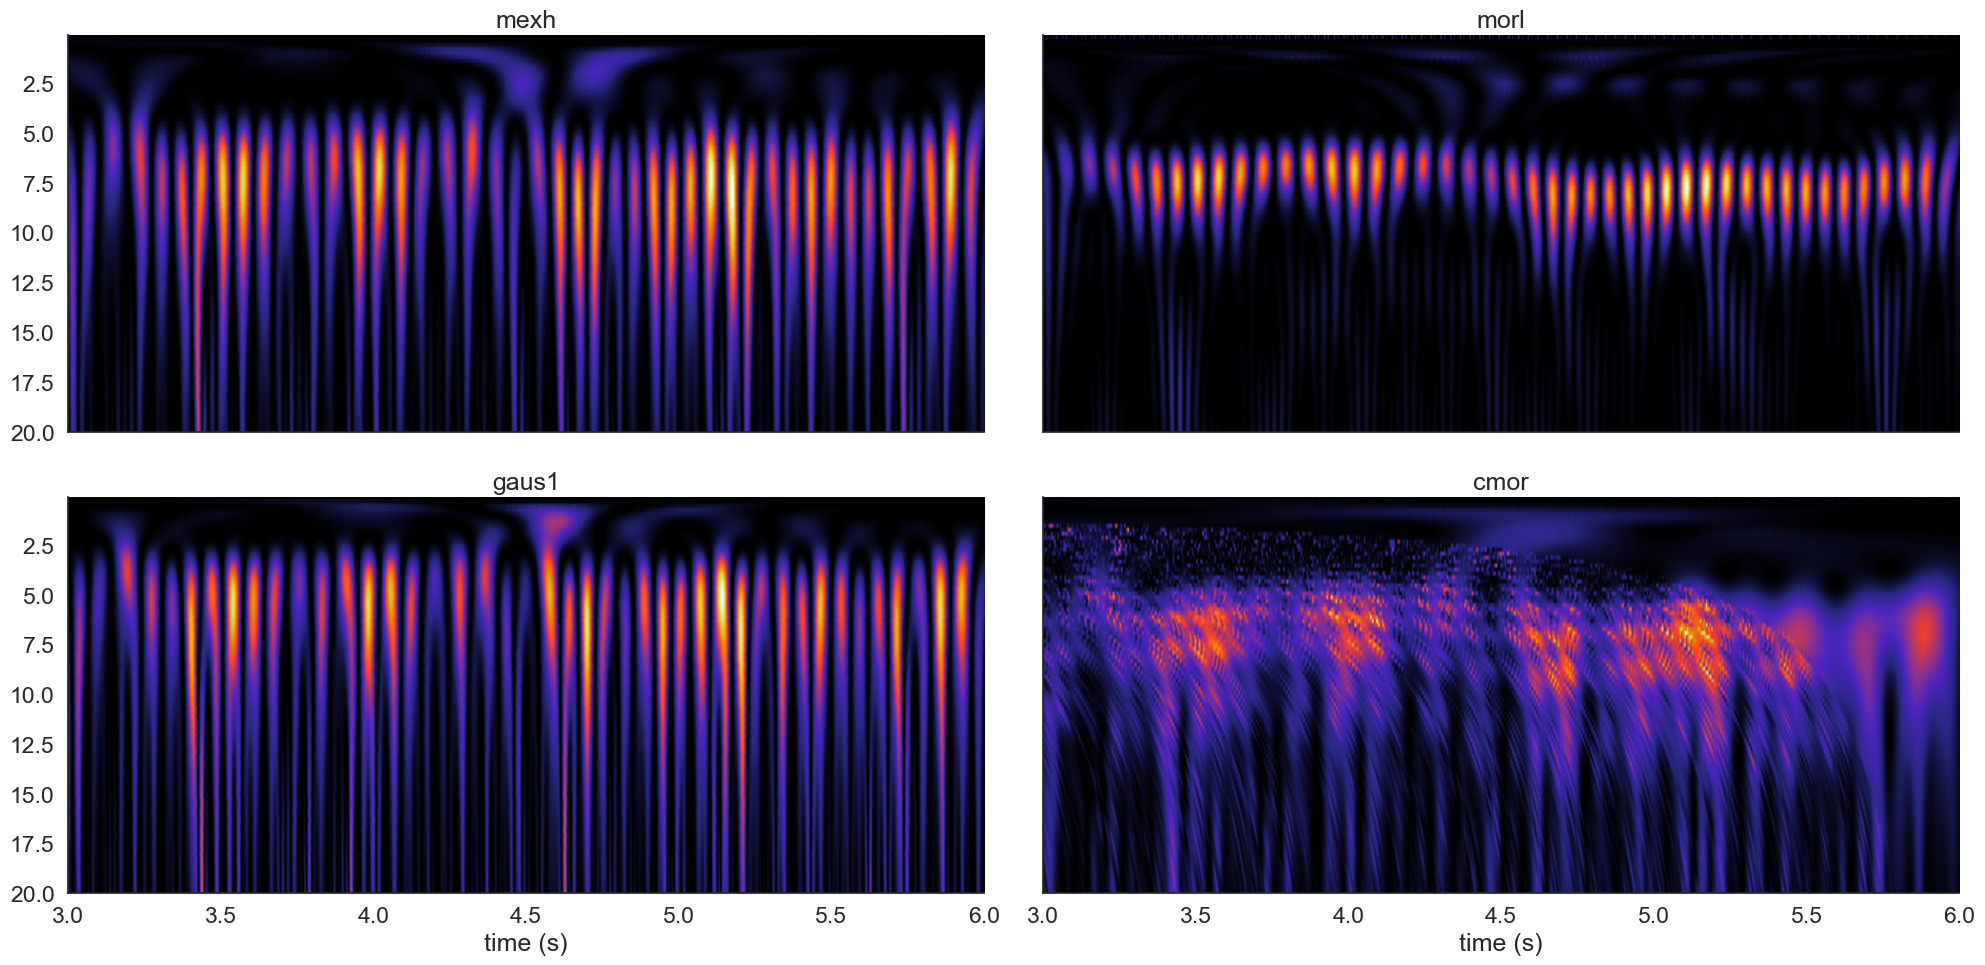

In [71]:
wavelets = ['mexh','gaus1','morl','cmor']

fig,axs = plt.subplots(2,2,figsize=(20,10),sharex=True,sharey=True)
frequencies =  np.linspace(0.1,20,100)/sampling_rate
i,j = 0,0

for wavelet in wavelets:
    scales = scale2frequency(wavelet, frequencies)
    cwtmatr, _ = cwt(centered_data_2, wavelet=wavelet, scales=scales,
                      sampling_period=1.0/sampling_rate)
    
    axs[i,j].imshow(abs(cwtmatr)**2, extent=[t_start,t_end,frequencies[-1]*sampling_rate,
                             frequencies[0]*sampling_rate], aspect='auto', cmap='CMRmap')
    axs[1,j].set_xlabel('time (s)')
    axs[i,j].set_title(f'{wavelet}')
    i += 1
    if i >1: 
        j += 1
        i = 0
fig.tight_layout() 
plt.show()
plt.close()


__Some Comments:__
- There are quite big differences between the different wavelets. The Gaussian and Mexican hat wavelets find a lot more high frequency signals (as can be seen by the purple 'smears' in their figures.
- The real Morlet wavelet mostly finds the theta wave, but not really any other persistant signals. There are some splashes of purple, where he finds some signal, but it is mostly just the theta wave.
- The complex Morlet wavelet gives the most "smeared out" figure. It mostly resembles the real Morlet figure, which makes sense. But it also looks more like a smoothing function passed over it. This is most likely due to the waves of the frequencies having different phases, resulting in some blurring of the transform. 

## Exercise 3: REM sleep detection
---
Mammalian sleep is organized in different phases. [Rapid Eye Movement (REM) sleep](https://en.wikipedia.org/wiki/Rapid_eye_movement_sleep) is a well studied phase, with clear markers that make it detectable from LFP data. One of the most used marker is the ratio (or difference) between the oscillatory power in the theta and delta bands in the hippocampus. During REM sleep, the former dominates, in a pattern that resembles active behaviour.  
In this exercise we will use the tools we learned about to detect and inspect the REM and non-REM (nREM) phases of sleep in data recorded from the hippocampus of a sleeping mouse.

- Import the data form `data/sleep_lfp.pickle`
- Compute the instantaneous power in the theta (6-10 Hz) and delta (2-4 Hz) frequency bands, for the whole signal.
- z-score the two power signals (subtract the mean and divide by the standard deviation, you can use `scipy.stats.zscore()`)
- Compute and plot the power difference (`theta_power - delta_power`) for the sleep session.
- Compute the REM (power difference $>0.2$) and nREM (power diffewrence $<0.2$) sleep periods.
- Plot examples of REM vs nREM lfp signals (wideband filtered betw. 1 and 200 Hz to get rid of some of the noise).
- Explore how changing the threshold affects the amount of REM sleep detected.

In [72]:
from ipywidgets import interact
import ipywidgets as widgets
import pywt
from pywt import wavelist
from pywt import scale2frequency
from pywt import cwt
from scipy.fft import fft, fftfreq
from scipy.signal import butter
from scipy.signal import sosfilt

In [143]:
with open('data/sleep_lfp.pickle', 'rb') as handle:
    lfp_data = pickle.load(handle)

lfp = lfp_data['lfp']
sampling_rate = lfp_data['sampling_rate']
print(f'Loaded {len(lfp)/sampling_rate} seconds of LFP, sampled at {sampling_rate} Hz')
print(f'Loaded {np.round((len(lfp)/sampling_rate)/60.)} minutes')

Loaded 1816.576 seconds of LFP, sampled at 1000.0 Hz
Loaded 30.0 minutes


In [82]:
def Instant_Power(signal,low_f=1,high_f=40000,sampling_rate=1000.,UseBand=True,DeAveraged=False):
    '''A function that calculates the instantaneous power of a wave band of a signal'''
    if not DeAveraged: signal = signal - np.mean(signal)
    wave_signal = lf.bandpass_filter(signal,low_f=low_f,high_f=high_f,sampling_rate=sampling_rate) if UseBand else signal
    return abs(wave_signal)**2

ThetaPower = Instant_Power(lfp,low_f=6,high_f=10,sampling_rate=sampling_rate)
DeltaPower = Instant_Power(lfp,low_f=2,high_f=4,sampling_rate=sampling_rate)
TotalPower = Instant_Power(lfp,sampling_rate=sampling_rate,UseBand=False)

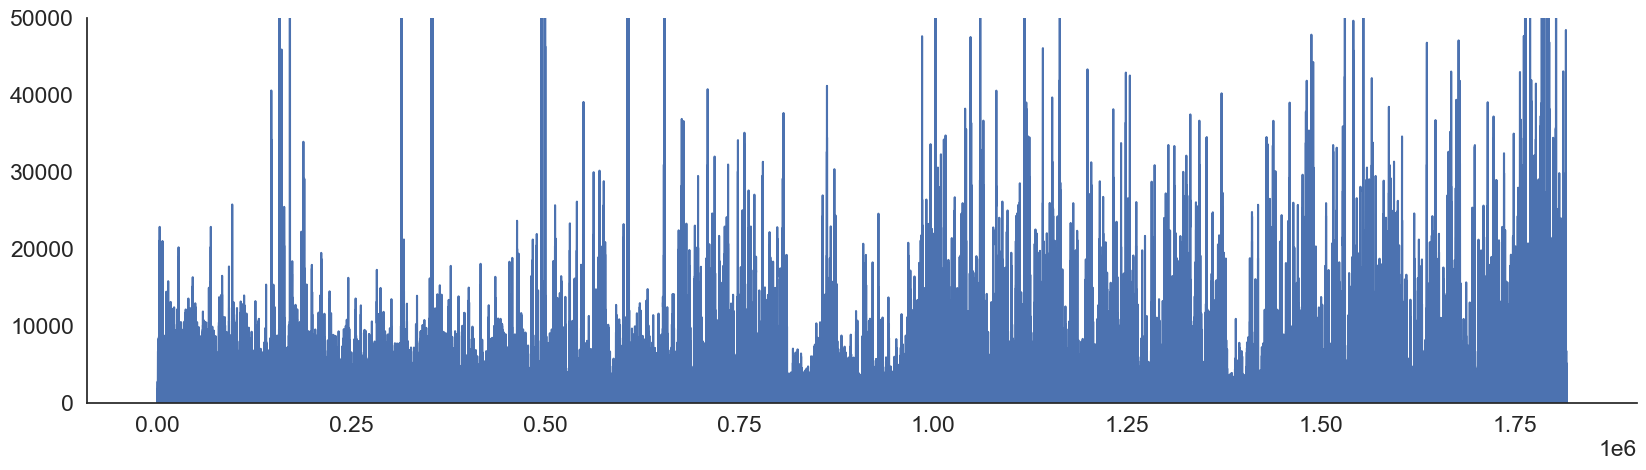

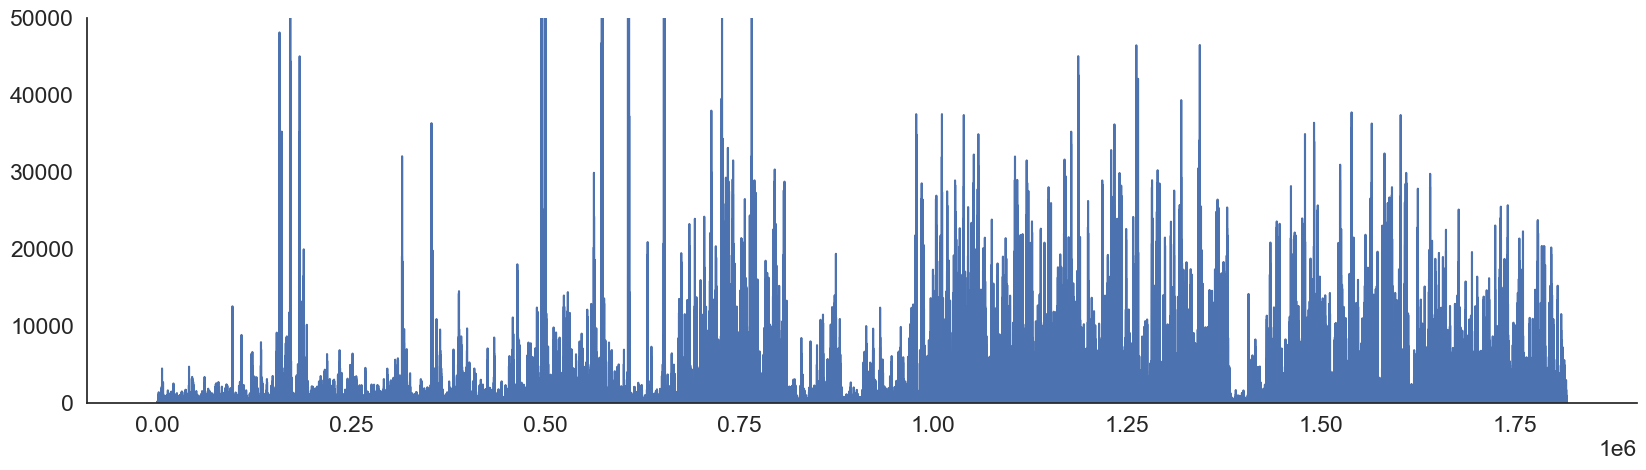

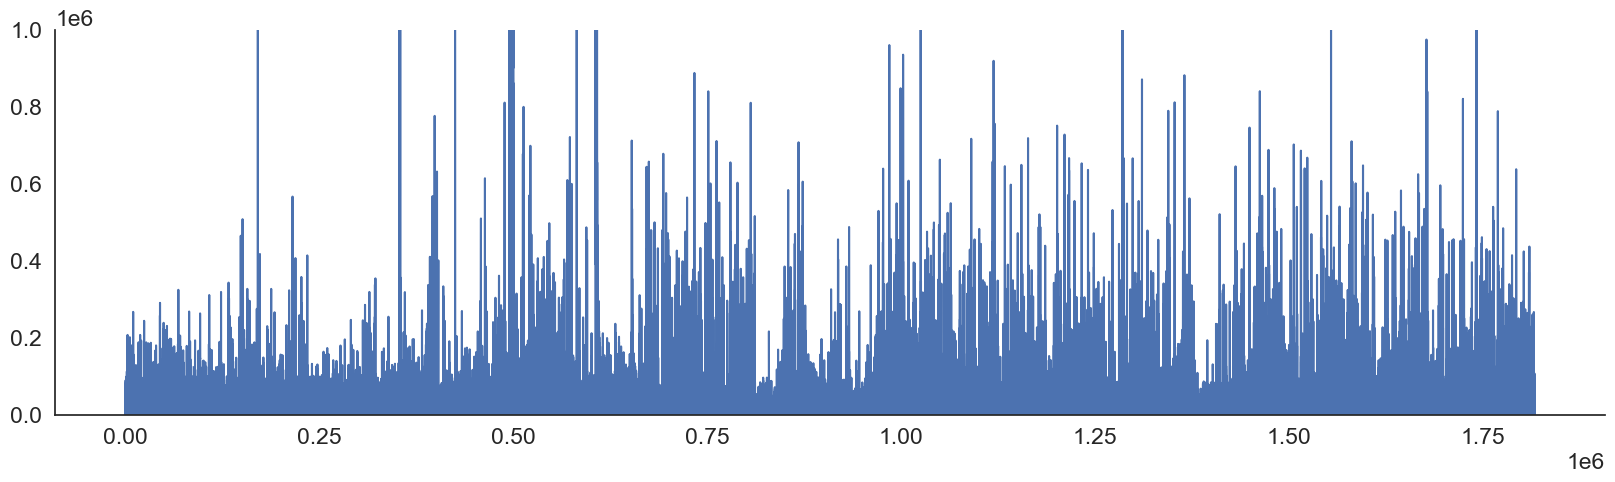

In [132]:
plt.figure(figsize=(20,5))
plt.plot(ThetaPower)
plt.ylim(0,50000)
plt.show()
plt.close()

plt.figure(figsize=(20,5))
plt.plot(DeltaPower)
plt.ylim(0,50000)
plt.show()
plt.close()

plt.figure(figsize=(20,5))
plt.plot(TotalPower)
plt.ylim(0,1000000)
plt.show()
plt.close()

In [100]:
ThetaZ = scipy.stats.zscore(ThetaPower)
DeltaZ = scipy.stats.zscore(DeltaPower)
TotalZ = scipy.stats.zscore(TotalPower)

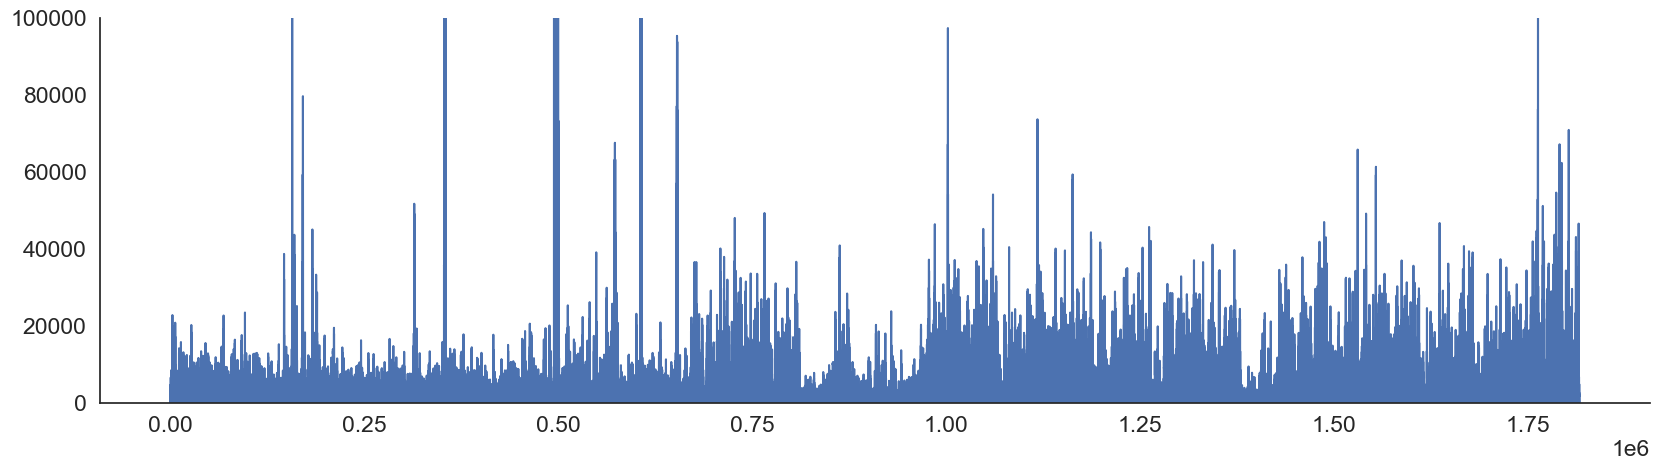

In [137]:
PowerDif = abs(ThetaPower-DeltaPower)
PowerDifZ = abs(ThetaZ-DeltaZ)
plt.figure(figsize=(20,5))
plt.plot(PowerDif)
plt.ylim(0,1e5)
plt.show()


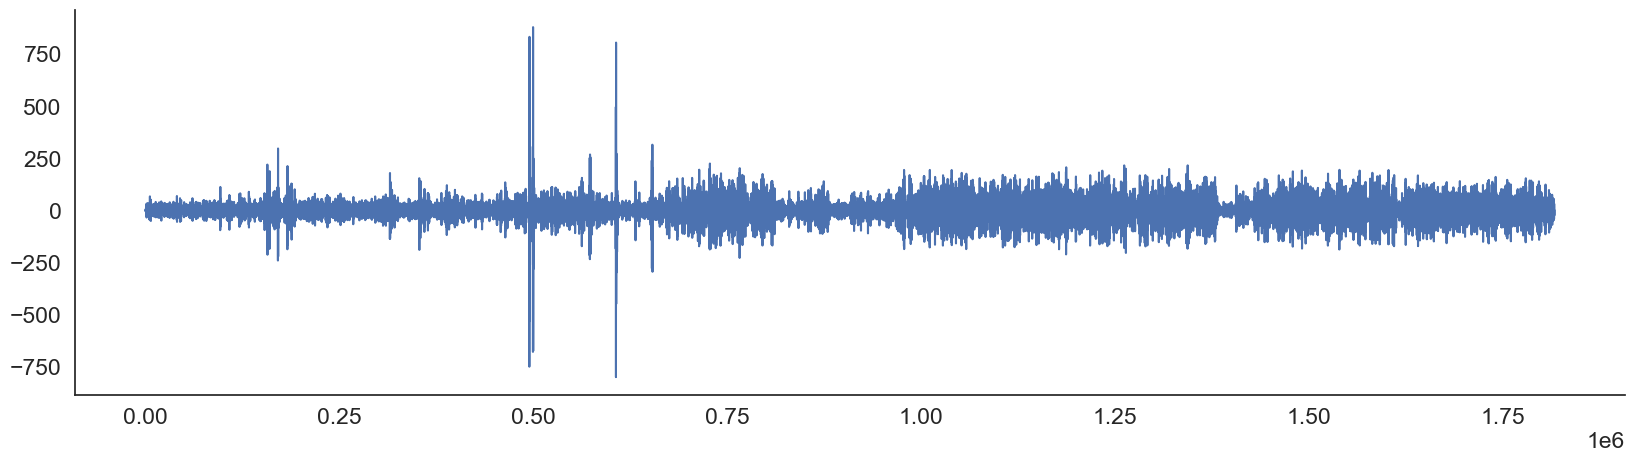

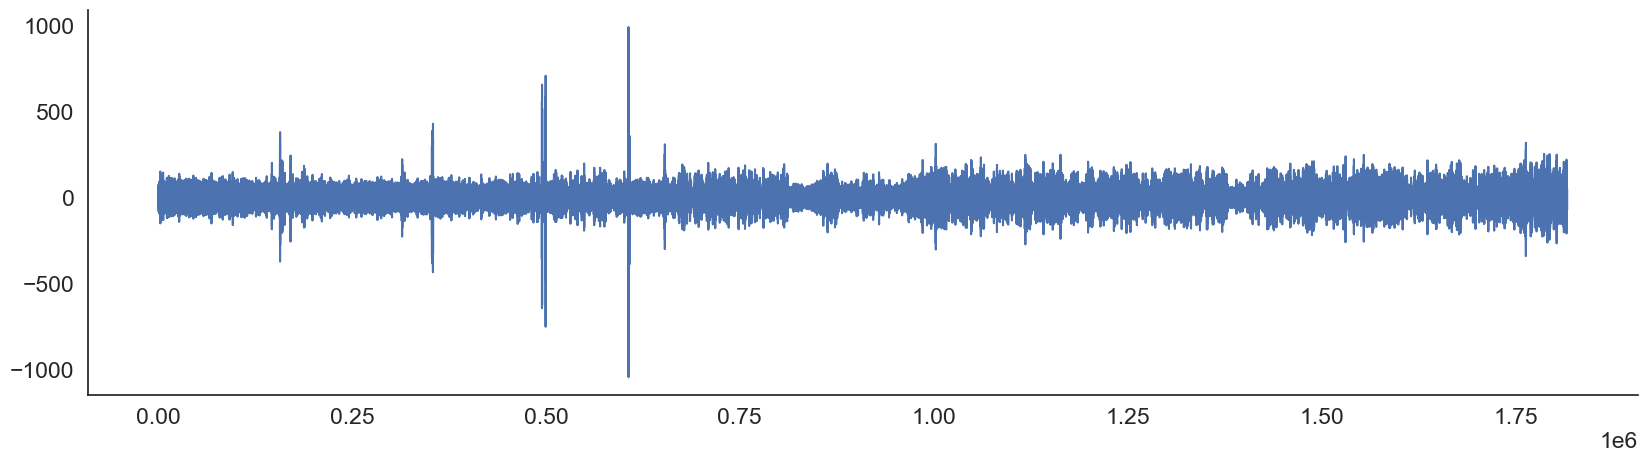

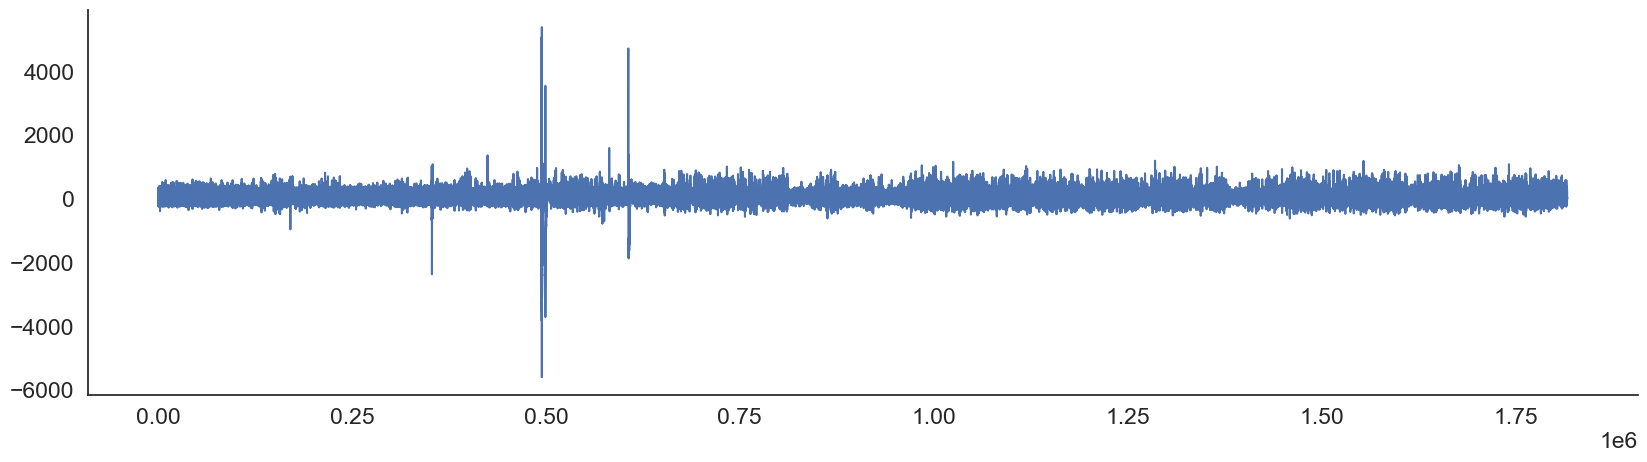

In [113]:
sig = lf.bandpass_filter(lfp,low_f=2,high_f=4,sampling_rate=sampling_rate)
plt.figure(figsize=(20,5))
plt.plot(sig)
#plt.ylim(0,10)
plt.show()

sig = lf.bandpass_filter(lfp,low_f=6,high_f=10,sampling_rate=sampling_rate)
plt.figure(figsize=(20,5))
plt.plot(sig)
#plt.ylim(0,10)
plt.show()

plt.figure(figsize=(20,5))
plt.plot(lfp)
#plt.ylim(0,10)
plt.show()



18


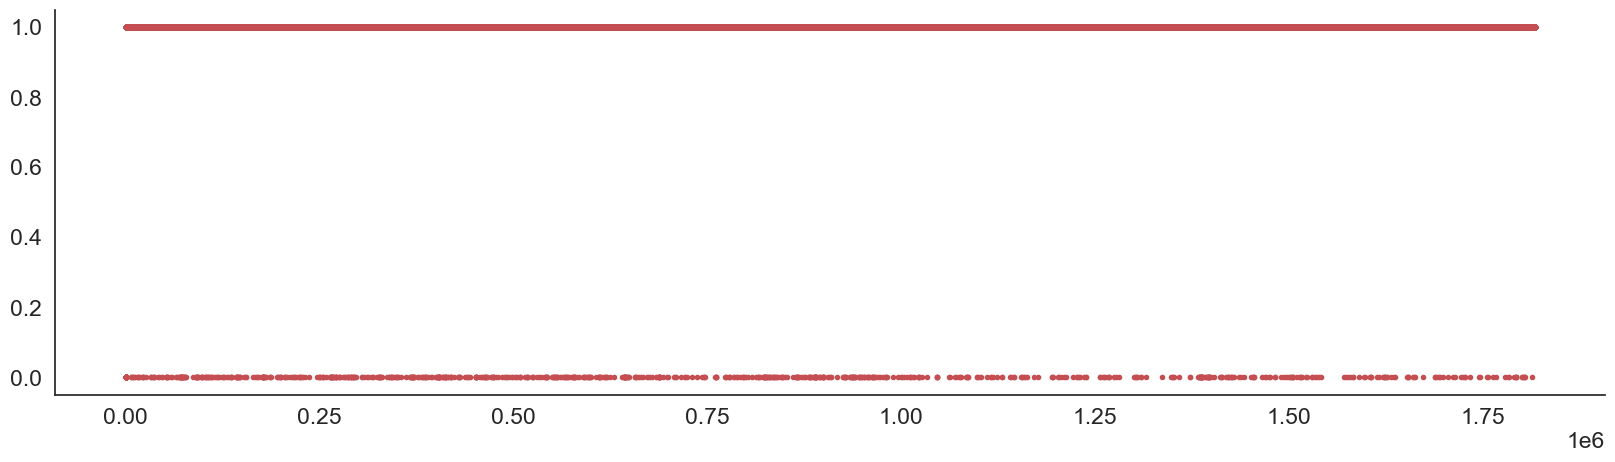

In [144]:
REMM = np.heaviside(PowerDif-.2,0)
t = np.arange(len(REMM))
figlength = 100000
print(len(REMM)//figlength)
#for i in range(len(REMM)//figlength):
#    plt.figure(figsize=(20,5))
#    plt.plot(t[i*figlength:(i+1)*figlength],REMM[i*figlength:(i+1)*figlength],'r.')
#    plt.show()

plt.figure(figsize=(20,5))
plt.plot(REMM,'r.')
plt.show()

In [145]:
fil_length = 10
REMMs = np.empty(REMM.shape)
for i in range(len(REMM)):
    if i <= fil_length:
        REMMs[i] = np.mean(REMM[0:i+fil_length])
    elif i>= len(REMM)-fil_length:
        REMMs[i] = np.mean(REMM[i-fil_length:-1])
    else:
        REMMs[i] = np.mean(REMM[i-fil_length:i+fil_length])

print(REMMs)

[0. 0. 0. ... 1. 1. 1.]


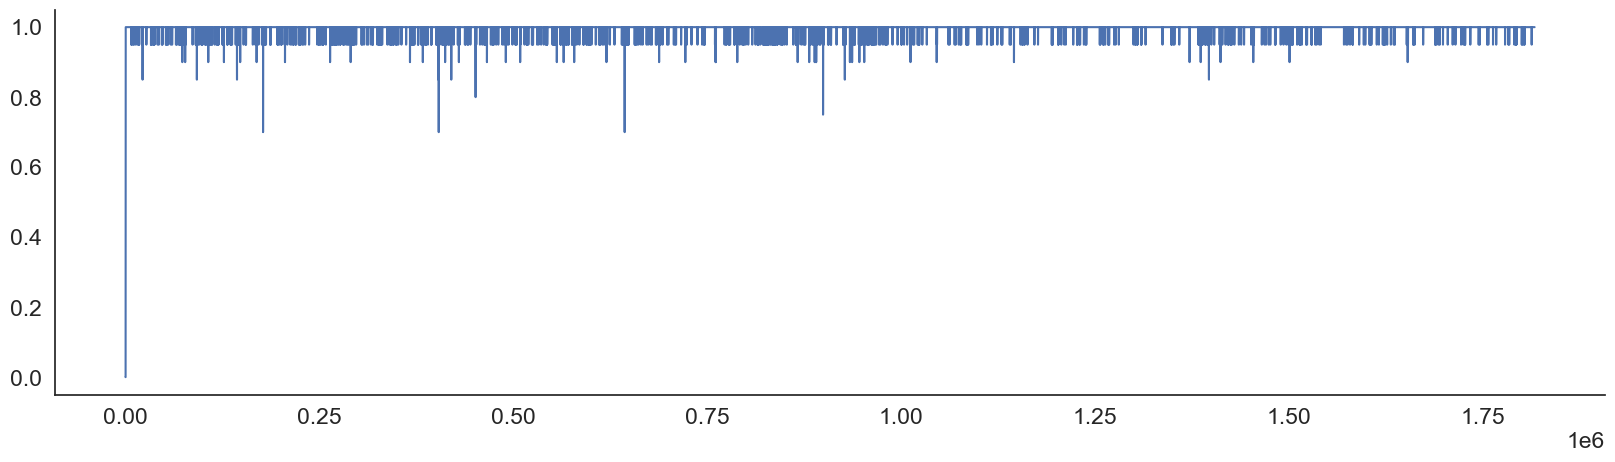

In [146]:
plt.figure(figsize=(20,5))
plt.plot(REMMs)
plt.show()